In [4]:
import numpy as np
import matplotlib.pyplot as plt
x = np.array([1, 2, 3, 4, 5, 5.5, 6.25, 7, 7.5, 7.75, 8, 9, 10, 11, 11.25, 11.5, 12, 13, 14.25, 14.75])
y = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])

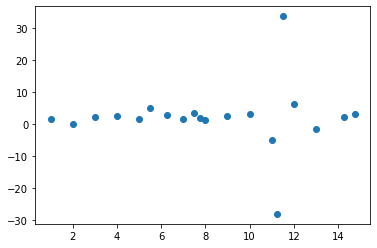

In [5]:
plt.scatter(x,y)

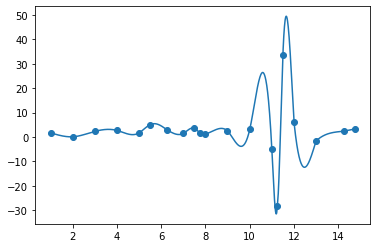

In [28]:
import numpy as np
import matplotlib.pyplot as plt
def setup_tridiagonal_matrix(x, y):
    n = len(x)
    h = np.diff(x)  # Step sizes between data points
    # Initialize the tridiagonal matrix coefficients
    A = np.zeros(n - 2)  # Subdiagonal
    B = np.zeros(n - 2)  # Main diagonal
    C = np.zeros(n - 2)  # Superdiagonal
    D = np.zeros(n - 2)  # Right-hand side vector
    # Populate the tridiagonal matrix coefficients
    for i in range(1, n - 1):
        A[i - 1] = h[i-1]             # Subdiagonal
        B[i - 1] = 2 * (h[i-1] + h[i])             # Main diagonal
        C[i - 1] = h[i]             # Superdiagonal
        D[i - 1] = 6 * ((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])           # Right-hand side vector
    return A, B, C, D

def thomas_algorithm(a, b, c, d):
    """
    Solve the tridiagonal system using the Thomas algorithm.
    a: sub-diagonal elements (length n-1)
    b: main diagonal elements (length n)
    c: super-diagonal elements (length n-1)
    d: right-hand side (length n)
    Returns: solution vector x of length n
    """
    n = len(b)
    # Forward elimination
    for i in range(1, n):
        w = a[i-1] / b[i-1]
        b[i] = b[i] - w * c[i-1]
        d[i] = d[i] - w * d[i-1]
    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]
    
    for i in range(n-2, -1, -1):
        x[i] = (d[i] - c[i] * x[i+1]) / b[i]
    return x


def custom_cubic_spline(x, y):
    evalx = x
    evaly = y
    a, b, c, d = setup_tridiagonal_matrix(x, y)
    M = np.array([0.0, *thomas_algorithm(a, b, c, d), 0.0], dtype=float)
    length = 0
    for i in range(len(x)-1):
        length = length + (((x[i+1]-x[i]) * 100))
    length = int(length)
    yreturn = np.zeros(length)
    xreturn = np.linspace(x[0], x[len(x)-1], length)
    prev_idx = 0
    for i in range(len(x)-1):
        xinterp = np.arange(x[i], x[i+1], 0.01)
        h = x[i+1]-x[i]
        yreturn[prev_idx:prev_idx + int((x[i+1]-x[i]) * 100)] = (M[i]/(6 * h)) * (x[i+1]-xinterp)**3 + \
        (M[i+1]/(6 * h)) * (xinterp-x[i])**3 + (y[i]/h - (M[i] * h)/6) * (x[i+1]-xinterp) + \
        (y[i+1]/h - (M[i+1] * h)/6) * (xinterp-x[i])
        prev_idx = prev_idx + int((x[i+1]-x[i]) * 100)
            
        
    return xreturn, yreturn


x_interp, y_interp = custom_cubic_spline(x, y)

plt.scatter(x, y)
plt.plot(x_interp, y_interp)


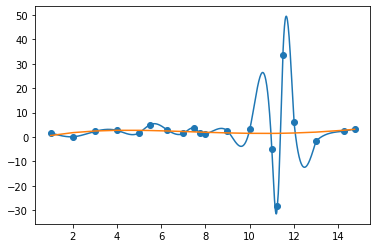

In [39]:
def create_vandermonde_matrix(degree, x):
    V = np.zeros(shape=((degree+1), len(x)))
    for i in range(degree+1):
        V[i] = (x.T ** i)
    V = V.T
    return V
def create_vandermonde_polynomial(degree, x, y):
    V = create_vandermonde_matrix(degree, x)
    VT_V = np.dot(V.T, V)
    VT_y = np.dot(V.T, y)
    coefficients = np.linalg.solve(VT_V, VT_y)
    polynomial = np.zeros(len(x))
    for i in range(degree+1):
        polynomial += ((x**i) * coefficients[i])
    return polynomial
polynomial = create_vandermonde_polynomial(4, x, y)

plt.scatter(x, y)
plt.plot(x_interp, y_interp)
plt.plot(x, polynomial)


-0.007627952755905512


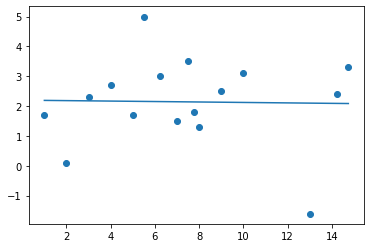

In [37]:
def my_lstsq(X, Y):
    n = len(X)
    sumX = np.sum(X)
    sumY = np.sum(Y)
    sumx2 = np.sum(X**2)
    sumA = np.sum(X * Y)
    m = (n * sumA - sumX * sumY) / (n * sumx2 - sumX**2)
    c = (sumY - m * sumX) / n
    return m, c

xlstsq = np.array([1, 2, 3, 4, 5, 5.5, 6.25, 7, 7.5, 7.75, 8, 9, 10, 13, 14.25, 14.75])
ylstsq = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -1.6, 2.4, 3.3])
m, c = my_lstsq(xlstsq, ylstsq)
print(m)
plt.scatter(xlstsq, ylstsq)
ylstsq = xlstsq * m + c
plt.plot(xlstsq, ylstsq)
